## Load Env

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

## Create LLM

In [3]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
import os

llm = ChatNVIDIA(model=os.environ.get('LLM_MODEL'))
llm

ChatNVIDIA(base_url='https://integrate.api.nvidia.com/v1', model='meta/llama-3.1-405b-instruct', default_headers={})

In [4]:
response = llm.invoke(input="Who are you?")
response.content

'I\'m an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."'

## Create Graph

### Schema

In [ ]:
from typing import TypedDict, NotRequired

class MainState(TypedDict):
    name: str
    location: str
    age: int
    message: str
    response: NotRequired[str]

### Node

In [6]:
def GreetingNode(state: MainState) -> MainState:
    name = state['name']
    loction = state['location']
    age = state['age']
    message = state['message']

    response = llm.invoke(input=f"{message}, My name is {name}, Location is {loction} and age is ${age}")

    state['response'] = str(response.content)

    return state

### Graph

In [7]:
from langgraph.graph import StateGraph, START, END

def get_grpah():
    my_graph = StateGraph(state_schema=MainState)

    my_graph.add_node('greeting', GreetingNode)
    my_graph.add_edge(START, 'greeting')
    my_graph.add_edge('greeting', END)

    return my_graph.compile()



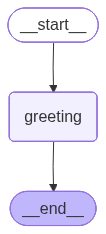

In [11]:
from IPython.display import Image

Image(get_grpah().get_graph().draw_mermaid_png())

In [10]:
get_grpah().invoke(input=MainState(
    name="Sam",
    location="Bangalore",
    age=30,
    message="Hello, LLM!"
))

{'name': 'Sam',
 'location': 'Bangalore',
 'age': 30,
 'message': 'Hello, LLM!',
 'response': "Hello Sam! Nice to meet you! I see you're from Bangalore, a vibrant city in India known for its tech industry and rich cultural heritage. And you're 30 years young! What brings you here today? Do you have any questions, topics you'd like to discuss, or perhaps something on your mind that you'd like to chat about? I'm all ears!"}